Step 1 — Imports & basic config

In [32]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.text import PP_ALIGN

# If you're in Jupyter, uncomment to show plots inline:
# %matplotlib inline

plt.rcParams["figure.figsize"] = (9, 4)


Step 2 — Define input/output paths


In [33]:
DATA_FILE = Path("2.RAW_DATA.xlsx")   # <-- change if your file is elsewhere

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

PLOT_OCC_PATH   = OUT_DIR / "plot_occupancy.png"
PLOT_RESP_PATH  = OUT_DIR / "plot_responsiveness.png"
PLOT_FALLS_PATH = OUT_DIR / "plot_falls.png"
PLOT_DIFF_PATH  = OUT_DIR / "plot_resp_vs_benchmark_diff.png"
SCAT_OCC_RESP   = OUT_DIR / "scatter_occ_vs_resp.png"
SCAT_RESP_FALLS = OUT_DIR / "scatter_resp_vs_falls.png"
SCAT_OCC_FALLS  = OUT_DIR / "scatter_occ_vs_falls.png"

CLEAN_CSV = OUT_DIR / "clean_kpi.csv"
CORR_CSV  = OUT_DIR / "correlations.csv"
PPT_PATH  = OUT_DIR / "Healthcare_KPI_Analysis.pptx"

assert DATA_FILE.exists(), f"Excel file not found: {DATA_FILE.resolve()}"


Step 3 — Load the Excel & clean the “Case Study Dataset”


In [23]:
xls = pd.ExcelFile(DATA_FILE)
raw = pd.read_excel(xls, sheet_name="Case Study Dataset")

kpi = pd.DataFrame({
    "month":                    raw["Unnamed: 1"].iloc[1:],
    "occupancy_rate":           raw["Unnamed: 2"].iloc[1:],  # may be % or 0–1
    "falls_per_1000_pd":        raw["Unnamed: 3"].iloc[1:],
    "unassisted_fall_pct":      raw["Unnamed: 4"].iloc[1:],  # likely 0–1
    "staff_resp_domain_pct":    raw["Unnamed: 5"].iloc[1:],  # likely 0–1
    "staff_resp_topbox_pct":    raw["Unnamed: 6"].iloc[1:],  # likely 0–1
    "staff_resp_benchmark_pct": raw["Unnamed: 7"].iloc[1:],  # often 65
}).reset_index(drop=True)

# Parse types
kpi["month"] = pd.to_datetime(kpi["month"], errors="coerce")
for c in ["occupancy_rate","falls_per_1000_pd","unassisted_fall_pct",
          "staff_resp_domain_pct","staff_resp_topbox_pct","staff_resp_benchmark_pct"]:
    kpi[c] = pd.to_numeric(kpi[c], errors="coerce")

# Convert decimals to percentages if most values are in 0–1
for c in ["occupancy_rate","unassisted_fall_pct","staff_resp_domain_pct","staff_resp_topbox_pct"]:
    vals = kpi[c].dropna()
    if len(vals) > 0 and (vals.between(0, 1).mean() > 0.7):
        kpi[c] = kpi[c] * 100

# Order by time and save a clean copy
kpi = kpi.dropna(subset=["month"]).sort_values("month").reset_index(drop=True)
kpi.to_csv(CLEAN_CSV, index=False)

kpi.head()


,month,occupancy_rate,falls_per_1000_pd,unassisted_fall_pct,staff_resp_domain_pct,staff_resp_topbox_pct,staff_resp_benchmark_pct
0,2020-01-01,96.0,2.21,68.34,22.1,68.34,65
1,2020-02-01,96.0,1.79,72.75,17.9,72.75,65
2,2020-03-01,81.0,1.03,67.07,10.3,67.07,65
3,2020-04-01,94.0,1.97,71.21,19.7,71.21,65
4,2020-05-01,101.0,3.41,57.68,34.1,57.68,65


Step 4 — Quick sanity checks

In [24]:
print("Date range:", kpi["month"].min().date(), "→", kpi["month"].max().date())
print(kpi[["month","occupancy_rate","staff_resp_topbox_pct","falls_per_1000_pd"]].head())


Date range: 2020-01-01 → 2024-12-01
       month  occupancy_rate  staff_resp_topbox_pct  falls_per_1000_pd
0 2020-01-01            96.0                  68.34               2.21
1 2020-02-01            96.0                  72.75               1.79
2 2020-03-01            81.0                  67.07               1.03
3 2020-04-01            94.0                  71.21               1.97
4 2020-05-01           101.0                  57.68               3.41


Step 5 — Helper for line plots (reusable)

In [25]:
def save_line_plot(x, y_list, labels, title, xlab, ylab, out_path):
    plt.figure()
    for y in y_list:
        plt.plot(x, y)
    if labels:
        plt.legend(labels)
    plt.title(title)
    plt.xlabel(xlab); plt.ylabel(ylab)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()


Step 6 — KPI trend charts

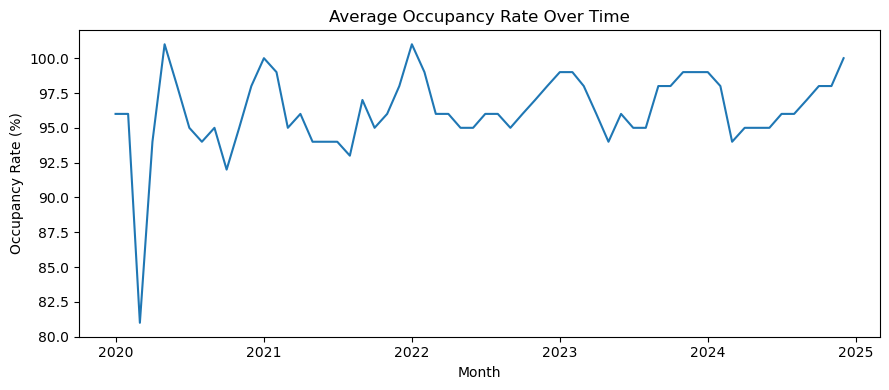

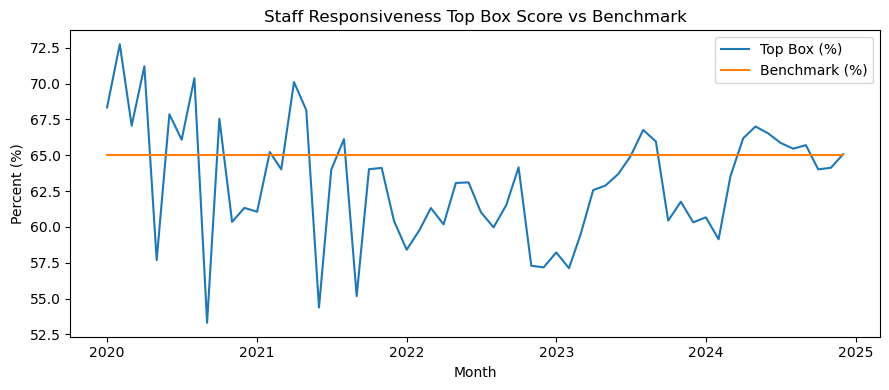

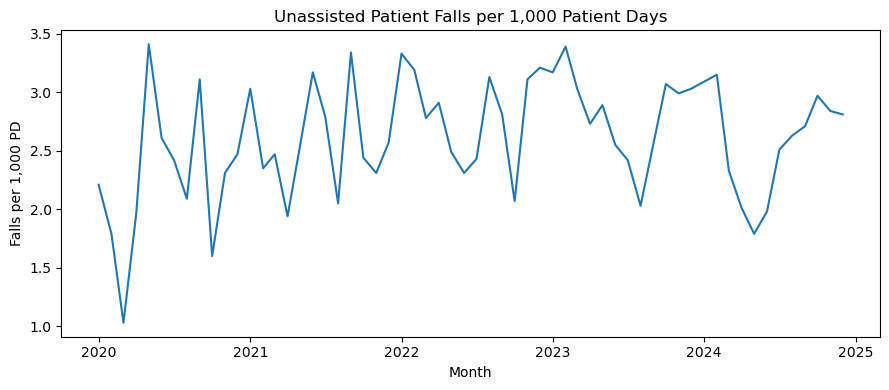

In [26]:
# 6a) Occupancy
save_line_plot(
    kpi["month"], [kpi["occupancy_rate"]], None,
    "Average Occupancy Rate Over Time", "Month", "Occupancy Rate (%)",
    PLOT_OCC_PATH
)

# 6b) Staff responsiveness vs benchmark
save_line_plot(
    kpi["month"], [kpi["staff_resp_topbox_pct"], kpi["staff_resp_benchmark_pct"]],
    ["Top Box (%)", "Benchmark (%)"],
    "Staff Responsiveness Top Box Score vs Benchmark",
    "Month", "Percent (%)",
    PLOT_RESP_PATH
)

# 6c) Unassisted falls per 1,000 patient days
save_line_plot(
    kpi["month"], [kpi["falls_per_1000_pd"]], None,
    "Unassisted Patient Falls per 1,000 Patient Days",
    "Month", "Falls per 1,000 PD",
    PLOT_FALLS_PATH
)


Step 7 — Benchmark difference (percentage points)

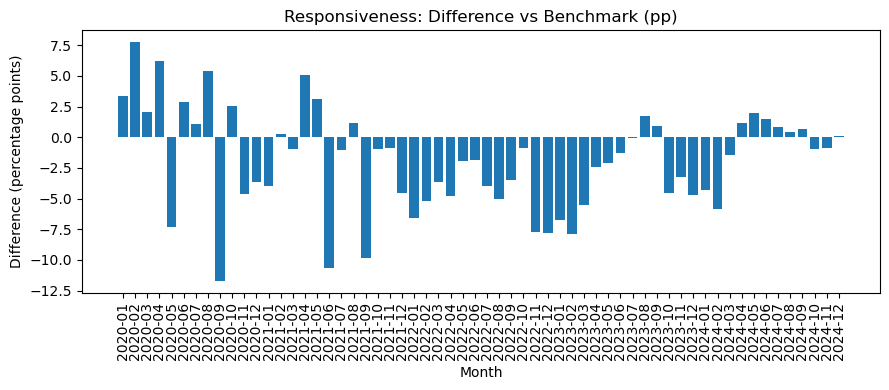

Months above benchmark: 21
Months below benchmark: 39


In [27]:
kpi["resp_diff_vs_bm"] = kpi["staff_resp_topbox_pct"] - kpi["staff_resp_benchmark_pct"]

plt.figure()
plt.bar(kpi["month"].dt.to_period("M").astype(str), kpi["resp_diff_vs_bm"])
plt.xticks(rotation=90)
plt.title("Responsiveness: Difference vs Benchmark (pp)")
plt.xlabel("Month"); plt.ylabel("Difference (percentage points)")
plt.tight_layout()
plt.savefig(PLOT_DIFF_PATH, dpi=150)
plt.show()

print("Months above benchmark:", int((kpi['resp_diff_vs_bm'] > 0).sum()))
print("Months below benchmark:", int((kpi['resp_diff_vs_bm'] < 0).sum()))


Step 8 — Correlations (Pearson) & save table

In [28]:
corr = kpi[["occupancy_rate","staff_resp_topbox_pct","falls_per_1000_pd"]].corr(method="pearson")
print(corr.round(3))
corr.to_csv(CORR_CSV)


                       occupancy_rate  staff_resp_topbox_pct  \
occupancy_rate                  1.000                 -0.372   
staff_resp_topbox_pct          -0.372                  1.000   
falls_per_1000_pd               0.700                 -0.791   

                       falls_per_1000_pd  
occupancy_rate                     0.700  
staff_resp_topbox_pct             -0.791  
falls_per_1000_pd                  1.000  


Step 9 — Relationship plots (scatter + best-fit line)

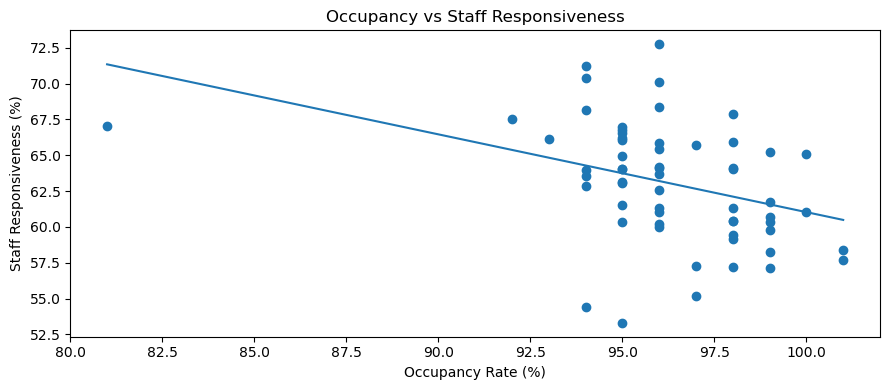

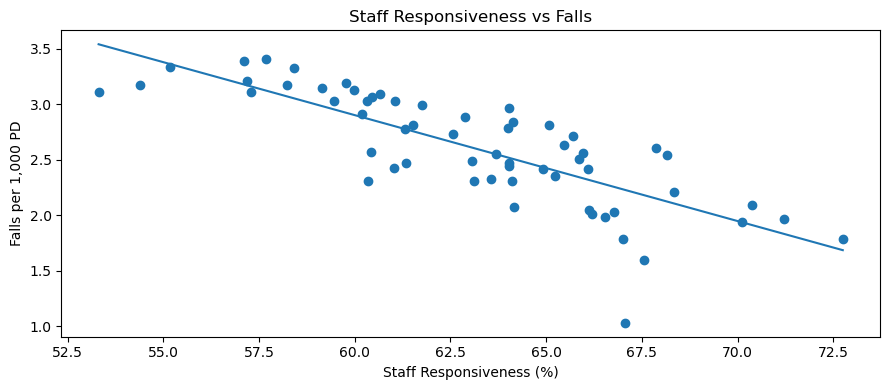

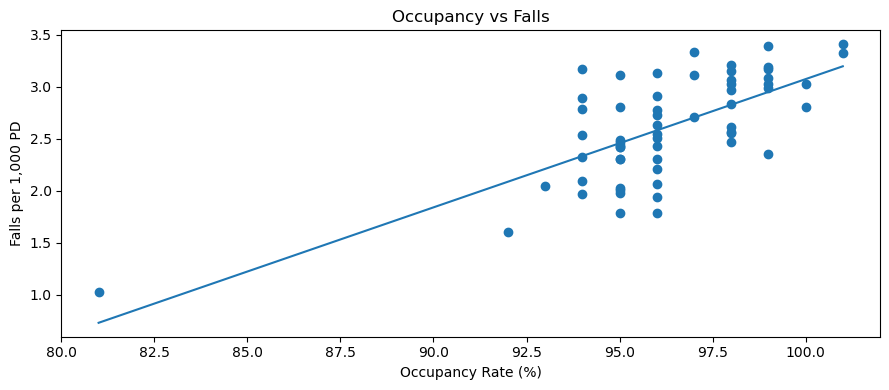

In [29]:
def scatter_with_fit(x, y, xlab, ylab, title, out_path):
    mask = ~(x.isna() | y.isna())
    xv = x[mask].to_numpy()
    yv = y[mask].to_numpy()
    plt.figure()
    plt.scatter(xv, yv)
    if len(xv) >= 2:
        m, b = np.polyfit(xv, yv, 1)
        xs = np.linspace(xv.min(), xv.max(), 100)
        ys = m*xs + b
        plt.plot(xs, ys)
    plt.title(title); plt.xlabel(xlab); plt.ylabel(ylab)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

scatter_with_fit(
    kpi["occupancy_rate"], kpi["staff_resp_topbox_pct"],
    "Occupancy Rate (%)", "Staff Responsiveness (%)",
    "Occupancy vs Staff Responsiveness", SCAT_OCC_RESP
)

scatter_with_fit(
    kpi["staff_resp_topbox_pct"], kpi["falls_per_1000_pd"],
    "Staff Responsiveness (%)", "Falls per 1,000 PD",
    "Staff Responsiveness vs Falls", SCAT_RESP_FALLS
)

scatter_with_fit(
    kpi["occupancy_rate"], kpi["falls_per_1000_pd"],
    "Occupancy Rate (%)", "Falls per 1,000 PD",
    "Occupancy vs Falls", SCAT_OCC_FALLS
)


Step 10 — Simple multivariate regression (quantify drivers of falls)

In [30]:
X = kpi[["occupancy_rate","staff_resp_topbox_pct"]].to_numpy()
y = kpi["falls_per_1000_pd"].to_numpy()

mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X_, y_ = X[mask], y[mask]

# Add intercept
X_design = np.c_[np.ones(len(X_)), X_]
beta, *_ = np.linalg.lstsq(X_design, y_, rcond=None)

intercept, coef_occ, coef_resp = beta
y_hat = X_design @ beta
ss_res = ((y_ - y_hat)**2).sum()
ss_tot = ((y_ - y_.mean())**2).sum()
r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

print(f"falls_per_1000_pd = {intercept:.3f} + {coef_occ:.3f}*occupancy + {coef_resp:.3f}*responsiveness")
print(f"R^2 = {r2:.3f}")


falls_per_1000_pd = -0.687 + 0.083*occupancy + -0.074*responsiveness
R^2 = 0.817


Step 11 — Build a PowerPoint with all visuals + insights

In [31]:
prs = Presentation()

# Title slide
slide = prs.slides.add_slide(prs.slide_layouts[0])
slide.shapes.title.text = "Hospital KPI Analysis"
slide.placeholders[1].text = "Occupancy, Staff Responsiveness, and Unassisted Falls (Case Study)"

def add_pic_slide(title, img_path: Path):
    s = prs.slides.add_slide(prs.slide_layouts[5])
    txbx = s.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(9), Inches(0.6))
    tf = txbx.text_frame
    tf.text = title
    tf.paragraphs[0].font.size = Pt(24)
    # use absolute path to avoid FileNotFoundError
    s.shapes.add_picture(str(img_path.resolve()), Inches(0.8), Inches(1.0), width=Inches(8.5))

for title, path in [
    ("Trend: Occupancy Rate", PLOT_OCC_PATH),
    ("Trend: Staff Responsiveness vs Benchmark", PLOT_RESP_PATH),
    ("Trend: Unassisted Falls per 1,000 PD", PLOT_FALLS_PATH),
    ("Benchmark Difference (pp)", PLOT_DIFF_PATH),
    ("Relationship: Occupancy vs Staff Responsiveness", SCAT_OCC_RESP),
    ("Relationship: Staff Responsiveness vs Falls", SCAT_RESP_FALLS),
    ("Relationship: Occupancy vs Falls", SCAT_OCC_FALLS),
]:
    assert Path(path).exists(), f"Missing image: {path}"
    add_pic_slide(title, Path(path))

# Correlations slide
slide = prs.slides.add_slide(prs.slide_layouts[5])
tx1 = slide.shapes.add_textbox(Inches(0.5), Inches(0.2), Inches(9), Inches(0.8))
tx1.text_frame.text = "Correlation Summary (Pearson r)"
tx1.text_frame.paragraphs[0].font.size = Pt(24)

tx2 = slide.shapes.add_textbox(Inches(0.5), Inches(1.1), Inches(9), Inches(4.5))
tx2.text_frame.text = corr.round(3).to_string()
tx2.text_frame.paragraphs[0].font.size = Pt(14)

# Key insights slide (auto bullets)
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Key Insights"
body = slide.placeholders[1].text_frame
body.text = "Highlights from the analysis:"
p = body.add_paragraph(); p.text = f"- Corr(Occupancy, Falls): {corr.loc['occupancy_rate','falls_per_1000_pd']:.2f}"; p.level = 1
p = body.add_paragraph(); p.text = f"- Corr(Responsiveness, Falls): {corr.loc['staff_resp_topbox_pct','falls_per_1000_pd']:.2f}"; p.level = 1
p = body.add_paragraph(); p.text = f"- Corr(Occupancy, Responsiveness): {corr.loc['occupancy_rate','staff_resp_topbox_pct']:.2f}"; p.level = 1
p = body.add_paragraph(); p.text = f"- Months above benchmark: {(kpi['resp_diff_vs_bm']>0).sum()}, below: {(kpi['resp_diff_vs_bm']<0).sum()}"; p.level = 1
p = body.add_paragraph(); p.text = f"- Regression R²: {r2:.2f}  |  falls ≈ {intercept:.2f} + {coef_occ:.3f}*occ + {coef_resp:.3f}*resp"; p.level = 1

prs.save(str(PPT_PATH.resolve()))
print("Saved PowerPoint:", PPT_PATH.resolve())


Saved PowerPoint: C:\Users\Akash Basavaraju\outputs\Healthcare_KPI_Analysis.pptx


Python Code (adds this slide to your PPT)

In [34]:
# --- Add Recommendations slide ---
slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Recommendations"

body = slide.placeholders[1].text_frame
body.text = "Based on findings, we recommend:"

recs = [
    "Staffing Adjustments: Increase staff coverage during months when occupancy >90%.",
    "Response Protocols: Implement a rapid call-button escalation system.",
    "Fall Prevention: Provide targeted training and monitoring in high-fall months.",
    "Benchmark Monitoring: Track responsiveness weekly vs. 65% benchmark; alert on dips.",
    "Continuous Improvement: Share KPI dashboards with leadership for proactive action."
]

for r in recs:
    p = body.add_paragraph()
    p.text = r
    p.level = 1

prs.save(str(PPT_PATH.resolve()))
print("Added Recommendations slide to:", PPT_PATH.resolve())


Added Recommendations slide to: C:\Users\Akash Basavaraju\outputs\Healthcare_KPI_Analysis.pptx
